[*********************100%***********************]  5 of 5 completed



Optimal Portfolio Weights
--------------------------
AAPL: 0.5213791423238971
MSFT: 0.21049898056782715
GOOGL: 1.2450667925825897e-16
AMZN: 0.26812187710827556
AMD: 0.0

Portfolio Metrics
-----------------
Expected Annual Return: 33.447817916961455%
Volatility (Risk): 30.216973426653514%
Sharpe Ratio: 1.0407335464385803


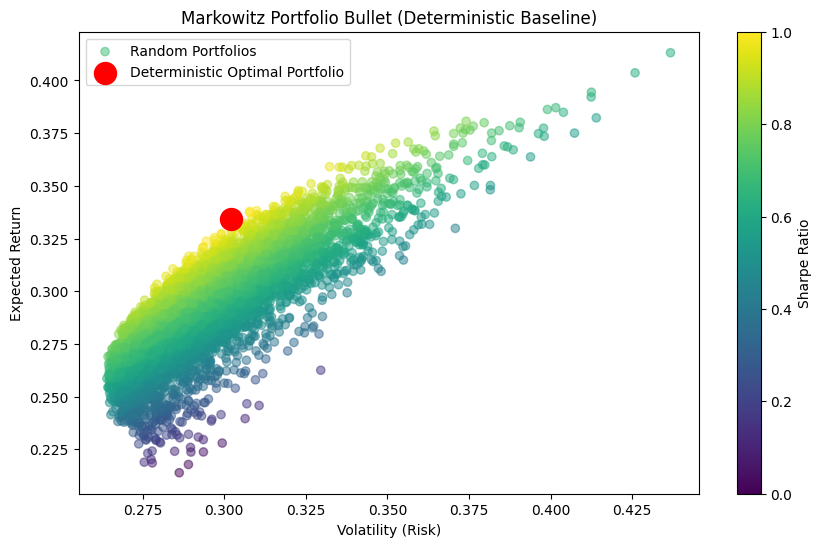

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf

# show full-length floating points in output
np.set_printoptions(precision=16, suppress=False, floatmode='maxprec')
pd.options.display.float_format = '{:.16f}'.format

# Defining basic parameters and assets
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "AMD"]
# tickers = ['TLT', 'GLD', 'SPY', 'QQQ', 'VWO']
start = "2019-01-01"
risk_free_rate = 0.02

# number of random portfolios for comparison
num_visual_samples = 5000

# Get the required data

data = yf.download(tickers, start=start)["Close"]
returns = data.pct_change().dropna()

# Annual statistics
mu = returns.mean() * 252
Sigma = returns.cov() * 252

num_assets = len(tickers)

# Basic functions to better help make the optimized portfolio

def portfolio_return(weights):
    return np.dot(weights, mu)

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ Sigma @ weights)

def sharpe_ratio(weights):
    r = portfolio_return(weights)
    v = portfolio_volatility(weights)
    return (r - risk_free_rate) / v

def negative_sharpe(weights):
    return -sharpe_ratio(weights)

# Optimize the weights using a deterministic approach and function

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0,1) for _ in range(num_assets))
initial = np.ones(num_assets) / num_assets

result = minimize(
    negative_sharpe,
    initial,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

# List optimized weights

print("\nOptimal Portfolio Weights")
print("--------------------------")

for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight}")

expected_return = portfolio_return(optimal_weights)
volatility = portfolio_volatility(optimal_weights)
sharpe = sharpe_ratio(optimal_weights)

print("\nPortfolio Metrics")
print("-----------------")
print(f"Expected Annual Return: {expected_return*100}%")
print(f"Volatility (Risk): {volatility*100}%")
print(f"Sharpe Ratio: {sharpe}")

# Calculate the random portfolio returns and risk

sample_returns = []
sample_vols = []
sample_sharpes = []

for _ in range(num_visual_samples):

    w = np.random.random(num_assets)
    w /= np.sum(w)

    r = portfolio_return(w)
    v = portfolio_volatility(w)
    s = sharpe_ratio(w)

    sample_returns.append(r)
    sample_vols.append(v)
    sample_sharpes.append(s)

# Plotting the this graphically

plt.figure(figsize=(10,6))

plt.scatter(
    sample_vols,
    sample_returns,
    c=sample_sharpes,
    alpha=0.5,
    label="Random Portfolios"
)

plt.scatter(
    volatility,
    expected_return,
    color="red",
    marker="o",
    s=250,
    label="Deterministic Optimal Portfolio"
)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Markowitz Portfolio Bullet (Deterministic Baseline)")

plt.colorbar(label="Sharpe Ratio")
plt.legend()

plt.show()

In [5]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "AMD"]
# tickers = ['TLT', 'GLD', 'SPY', 'QQQ', 'VWO']
start = "2019-01-01"
risk_free_rate = 0.02

n_samples = 5*1000
n_itr = 5*1000
mutation_prob = 0.1

data = yf.download(tickers, start=start)["Close"]
returns = data.pct_change().dropna()

mean = returns.mean() * 252
cvar = returns.cov() * 252

n_assets = len(tickers)

[*********************100%***********************]  5 of 5 completed


In [6]:
def portfolio_return(w):
	return np.dot(w, mean)

def portfolio_volatility(w):
	return np.sqrt(w.T @ cvar @ w)

def sharpe_ratio(w):
	r = portfolio_return(w)
	v = portfolio_volatility(w)
	return (r - risk_free_rate) / v

In [7]:
def gen_sample(sample_count, asset_count):
	samples = np.random.dirichlet(np.ones(asset_count), size=sample_count)
	for i in range(len(samples)):
		samples[i] /= np.sum(samples[i])
	return samples

def max_sharpe_and_weights(sample_space):
	sample_sharpe = np.array([sharpe_ratio(w) for w in sample_space])
	max_sharpe = max(sample_sharpe)
	best_weight = sample_space[np.argmax(max_sharpe)].copy()
	return max_sharpe, best_weight

In [8]:
def random_walks(n_sample_spaces, itr, n_samples, n_asset, n_particle):
	noise = 0.1
	gBest = []
	mutation_prob = 0.2
	for s in range(n_sample_spaces):
		samples = gen_sample(sample_count=n_samples, asset_count=n_asset)
		indices = np.random.choice(len(samples), size=n_particle, replace=False)
		particle = samples[indices].copy()
		# particle = np.random.dirichlet(np.ones(n_asset), size=n_particle)
		velocity = np.random.randn(n_particle, n_asset) * 0.2
		pBest = particle.copy()
		pBest_weight = np.array([sharpe_ratio(w) for w in particle])
		itr_best = pBest[np.argmax(pBest_weight)].copy()
		for _ in range(itr):
			weights = np.random.uniform(0.4, 0.9)
			c1 = np.random.uniform(1.0, 2.5)
			c2 = np.random.uniform(1.0, 2.5)

			for i in range(n_particle):
				r1 = np.random.rand(n_asset)
				r2 = np.random.rand(n_asset)
				velocity[i] = (
					weights * velocity[i]
					+ c1 * r1 * (pBest[i] - particle[i])
					+ c2 * r2 * (itr_best - particle[i])
				)
				velocity[i] += np.random.normal(0, noise, n_asset)
				particle[i] += velocity[i]
				if np.random.rand() < mutation_prob:
					idx = np.random.randint(len(samples))
					particle[i] = samples[idx].copy()
				particle[i] = np.maximum(particle[i], 0)
				total = np.sum(particle[i])
				if total <= 1e-12 :
					idx = np.random.randint(len(samples))
					particle[i] = samples[idx].copy()
				particle[i] /= np.sum(particle[i])

				score = sharpe_ratio(particle[i])
				if score > pBest_weight[i]:
					pBest[i] = particle[i].copy()
					pBest_weight[i] = score
			k = max(5, n_particle // 3)
			top_indices = np.argsort(pBest_weight)[-k:]
			chosen = np.random.choice(top_indices)
			itr_best = pBest[chosen].copy()
		gBest.append(itr_best)
	return gBest

In [14]:
gbest = random_walks(20, n_itr, n_samples, n_assets, 40)
gbest = np.array(gbest)

best_return_sharpe = 0
best_return_weights = []
run : int = 0
for i in gbest:
	run += 1
	print("--------------------------")
	print(f"-----Simulation {run} Run-----")
	print("Randomized PSO Portfolio")
	print("--------------------------")
	for t, w in zip(tickers, i):
		print(f"{t}: {w}")

	ret = portfolio_return(i)
	vol = portfolio_volatility(i)
	sharpe = sharpe_ratio(i)
	if sharpe > best_return_sharpe:
		best_return_sharpe = sharpe
		best_return_weights = i

	print("\nMetrics")
	print("--------------------------")
	print(f"Expected Return: {ret*100}%")
	print(f"Volatility: {vol*100}%")
	print(f"Sharpe Ratio: {sharpe}")

print("--------------------------")
print("---Best Simulation Run----")
print("Randomized PSO Portfolio")
print("--------------------------")
for t, w in zip(tickers, best_return_weights):
	print(f"{t}: {w}")

ret = portfolio_return(best_return_weights)
vol = portfolio_volatility(best_return_weights)
sharpe = sharpe_ratio(best_return_weights)

print("\nMetrics")
print("--------------------------")
print(f"Expected Return: {ret*100}%")
print(f"Volatility: {vol*100}%")
print(f"Sharpe Ratio: {sharpe}")

--------------------------
-----Simulation 1 Run-----
Randomized PSO Portfolio
--------------------------
AAPL: 0.5202766730976502
MSFT: 0.21046131704198376
GOOGL: 0.0
AMZN: 0.269262009860366
AMD: 0.0

Metrics
--------------------------
Expected Return: 33.443688469494184%
Volatility: 30.213014293415906%
Sharpe Ratio: 1.0407332470744723
--------------------------
-----Simulation 2 Run-----
Randomized PSO Portfolio
--------------------------
AAPL: 0.5223452586437123
MSFT: 0.21019027462348555
GOOGL: 0.0
AMZN: 0.2674644667328023
AMD: 0.0

Metrics
--------------------------
Expected Return: 33.44484622776913%
Volatility: 30.21412580907003%
Sharpe Ratio: 1.0407332790786767
--------------------------
-----Simulation 3 Run-----
Randomized PSO Portfolio
--------------------------
AAPL: 0.52013158889984
MSFT: 0.21098188387567948
GOOGL: 0.0
AMZN: 0.2688865272244806
AMD: 0.0

Metrics
--------------------------
Expected Return: 33.45328233891991%
Volatility: 30.222231788942562%
Sharpe Ratio: 1.040

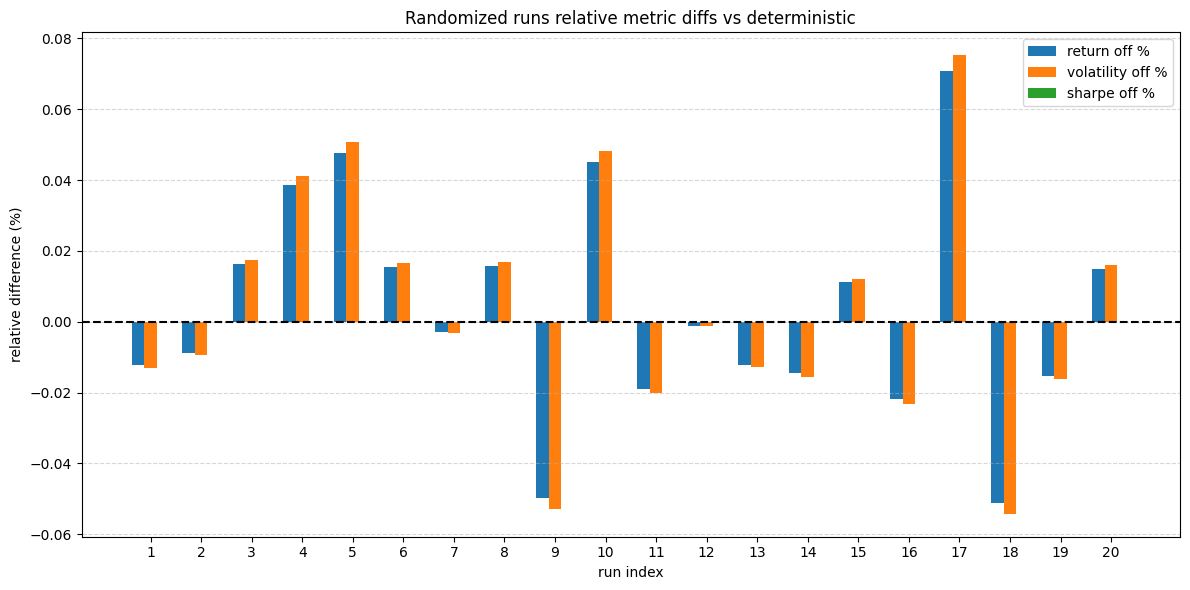

best run index by sharpe: 6
best run metrics:
return       0.3345303047936615
volatility   0.3022197496649216
sharpe       1.0407337877236313
Name: 5, dtype: float64
baseline metrics
return: 0.33447817916961453
volatility: 0.30216973426653515
sharpe: 1.0407337877236313


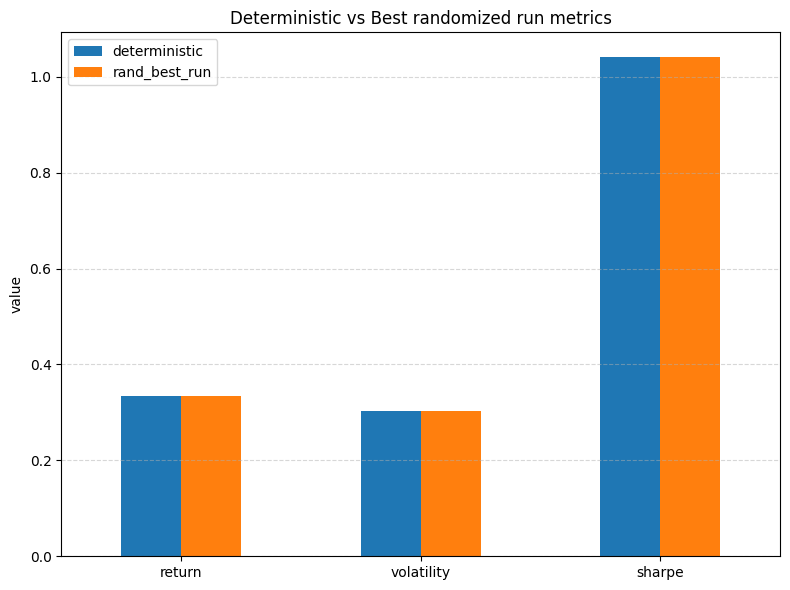

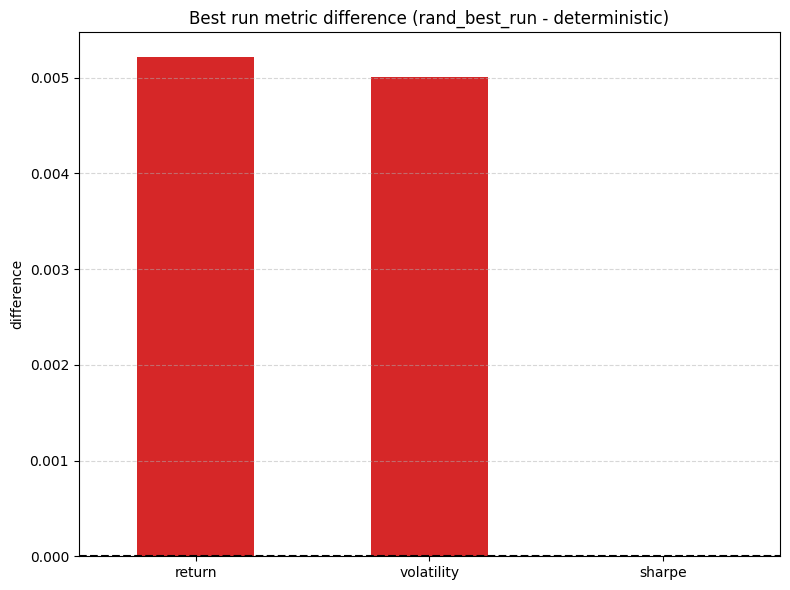

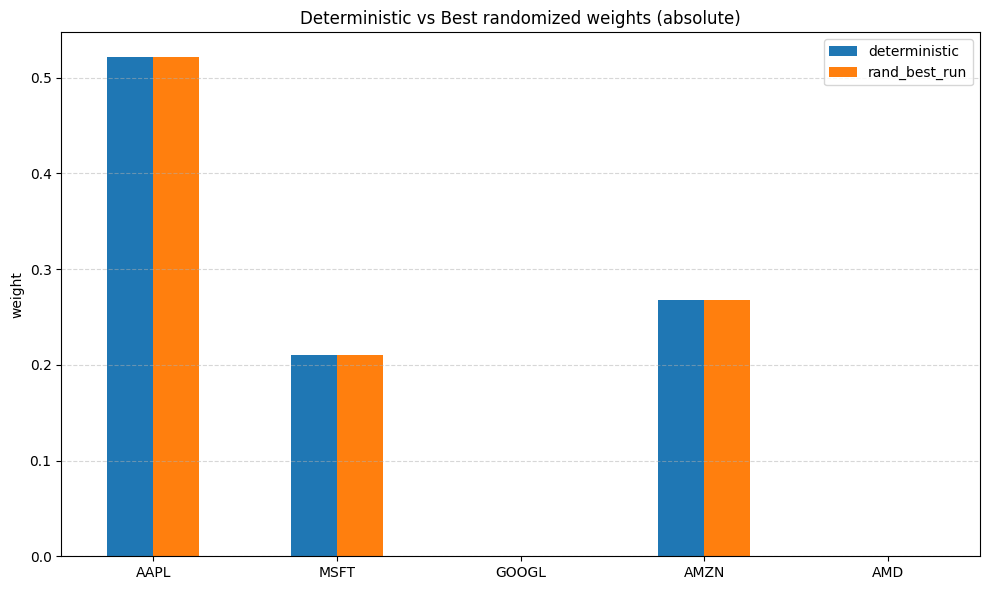

In [24]:
# compare each randomized run to deterministic baseline
# baseline values from already available variables
baseline_metrics = {
	"return": expected_return,
	"volatility": volatility,
	"sharpe": sharpe
}

df = pd.DataFrame(gbest, columns=[f"w_{t}" for t in tickers])

# make sure gbest exists and metrics df can be built
runs = len(gbest)
assert len(df) == runs, "df should have exactly one row per gbest run"

# augment df with deterministic and run metrics if missing
if "return" not in df.columns:
	df["return"] = [portfolio_return(w) for w in gbest]
	df["volatility"] = [portfolio_volatility(w) for w in gbest]
	df["sharpe"] = [sharpe_ratio(w) for w in gbest]

# relative metric differences to baseline (randomized minus deterministic)
for col in ["return", "volatility", "sharpe"]:
	df[f"{col}_off_pct"] = 100 * (df[col] - baseline_metrics[col]) / baseline_metrics[col]

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.25
x = np.arange(runs)
ax.bar(x - width, df["return_off_pct"], width, label="return off %", color="tab:blue")
ax.bar(x, df["volatility_off_pct"], width, label="volatility off %", color="tab:orange")
ax.bar(x + width, df["sharpe_off_pct"], width, label="sharpe off %", color="tab:green")
ax.axhline(0, color="black", linestyle="--")
ax.set_title("Randomized runs relative metric diffs vs deterministic")
ax.set_xlabel("run index")
ax.set_ylabel("relative difference (%)")
ax.set_xticks(x)
ax.set_xticklabels((x + 1).astype(int))
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

# highlight best run in metric terms
best_idx = df["sharpe"].idxmax()
print(f"best run index by sharpe: {best_idx + 1}")
print("best run metrics:")
print(df.loc[best_idx, ["return", "volatility", "sharpe"]])
print("baseline metrics")
print("return:", baseline_metrics["return"])
print("volatility:", baseline_metrics["volatility"])
print("sharpe:", baseline_metrics["sharpe"])

# deterministic vs best run bar chart for metrics
best_run_metrics = df.loc[best_idx, ["return", "volatility", "sharpe"]]
compare_metrics = pd.DataFrame({
	"deterministic": [baseline_metrics["return"], baseline_metrics["volatility"], baseline_metrics["sharpe"]],
	"rand_best_run": best_run_metrics.values
}, index=["return", "volatility", "sharpe"])

fig, ax = plt.subplots(figsize=(8, 6))
compare_metrics.plot(kind="bar", ax=ax)
ax.set_title("Deterministic vs Best randomized run metrics")
ax.set_ylabel("value")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# best run metric difference graph
best_diff = 100 * (compare_metrics["rand_best_run"] - compare_metrics["deterministic"])
fig, ax = plt.subplots(figsize=(8, 6))
best_diff.plot(kind="bar", ax=ax, color="tab:red")
ax.axhline(0, color="black", linestyle="--")
ax.set_title("Best run metric difference (rand_best_run - deterministic)")
ax.set_ylabel("difference")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# weight allocation comparison
weights_df = pd.DataFrame(gbest, columns=tickers)
weights_df["run"] = weights_df.index
baseline_weights = pd.Series(optimal_weights, index=tickers, name="deterministic")

# best run weights
best_run_weights = gbest[best_idx]
best_w = pd.Series(best_run_weights, index=tickers, name="best_run")

# absolute weight comparison: deterministic vs best
weights_comp = pd.DataFrame({"deterministic": baseline_weights, "rand_best_run": best_w})
fig, ax = plt.subplots(figsize=(10, 6))
weights_comp.plot(kind="bar", ax=ax)
ax.set_title("Deterministic vs Best randomized weights (absolute)")
ax.set_ylabel("weight")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()